<a href="https://colab.research.google.com/github/yiding2022/DAAI/blob/main/logit_model_and_simple_decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logit model

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm


In [ ]:
from google.colab import files

# Upload file
uploaded = files.upload()


Saving UniversalBank.csv to UniversalBank (2).csv


In [4]:
url = "https://raw.githubusercontent.com/yiding2022/DAAI/main/UniversalBank.csv"
bank_df = pd.read_csv(url)

In [ ]:
# Variable definition

# Personal loan ~ 1 means approval, 0 means rejection
# Age ~ Customer’s age in completed years
# Experience ~ Number of years of professional experience
# Income ~ Annual income of the customer ($000s)
# Family Size ~ Family size of the customer
# CCAvg ~ Average spending on credit cards per month ($000s)
# Education ~ Education Level. 1: Undergrad; 2: Graduate; 3: Advanced/Professional
# Mortgage ~ Value of house mortgage if any ($000s)
# Securities Account ~ Coded as 1 if customer has securities account with bank
# CD Account ~ Coded as 1 if customer has certificate of deposit (CD) account with bank
# Online Banking ~ Coded as 1 if customer uses Internet banking facilities
# Credit Card ~ Coded as 1 if customer uses credit card issued by Universal Bank

In [5]:
bank_df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [6]:
bank_df['Personal Loan'].value_counts()


,count
Personal Loan,
0,4520
1,480


In [7]:
# remove not relevant columns
bank_df.drop(columns=['ID', 'ZIP Code'], inplace=True)


In [8]:
bank_df

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,1,1.9,3,0,0,0,0,1,0
4996,30,4,15,4,0.4,1,85,0,0,0,1,0
4997,63,39,24,2,0.3,3,0,0,0,0,0,0
4998,65,40,49,3,0.5,2,0,0,0,0,1,0


In [9]:
# Treat education as categorical, convert to dummy variables

# In the dataset, it is coded as an integer, taking on values 1, 2, or 3. To turn it into a dummy variable, we first convert it into a categorical variable using
# the pandas methods astype(‘category’) and rename_categories. Then we apply the function pd.get_dummies on the data frame to create two dummy variables from the
# three categories. The logistic regression will only use two of the three categories because using all three would create a multicollinearity issue

bank_df['Education'] = bank_df['Education'].astype('category')
new_categories = {1: 'Undergrad', 2: 'Graduate', 3: 'Advanced/Professional'}
bank_df['Education'] = bank_df['Education'].cat.rename_categories(new_categories)
bank_df = pd.get_dummies(bank_df, prefix_sep='_', drop_first=True)

In [ ]:
bank_df

,Age,Experience,Income,Family,CCAvg,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,Education_Graduate,Education_Advanced/Professional
0,25,1,49,4,1.6,0,0,1,0,0,0,False,False
1,45,19,34,3,1.5,0,0,1,0,0,0,False,False
2,39,15,11,1,1.0,0,0,0,0,0,0,False,False
3,35,9,100,1,2.7,0,0,0,0,0,0,True,False
4,35,8,45,4,1.0,0,0,0,0,0,1,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,1,1.9,0,0,0,0,1,0,False,True
4996,30,4,15,4,0.4,85,0,0,0,1,0,False,False
4997,63,39,24,2,0.3,0,0,0,0,0,0,False,True
4998,65,40,49,3,0.5,0,0,0,0,1,0,True,False


In [ ]:
y = bank_df['Personal Loan']
X = bank_df.drop(columns=['Personal Loan'])

In [ ]:
import statsmodels.api as sm

# Add constant to the independent variables
X = sm.add_constant(X)

# Fit the logistic regression model
logit_model = sm.Logit(y, X.astype(float))
logit_result = logit_model.fit()


Optimization terminated successfully.
         Current function value: 0.117230
         Iterations 9


In [ ]:
# view the logit results
logit_result.summary()

# interpretation: exp(3.9654)
# holding others at a fixed value, the odds of getting a loan for graduate over the odds of getting into a loan for undergraduate
# is exp(3.9654) = 52.

# income: we will see 6.2% increase in the odds of getting a loan for a one-unit increase in income since exp(.0602) = 1.062


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:          Personal Loan   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4987
Method:                           MLE   Df Model:                           12
Date:                Wed, 29 Jan 2025   Pseudo R-squ.:                  0.6293
Time:                        13:09:32   Log-Likelihood:                -586.15
converged:                       True   LL-Null:                       -1581.0
Covariance Type:            nonrobust   LLR p-value:                     0.000
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                             -12.3105      1.818     -6.773      0.000     -15.873      -8.748
Age                                -0.0359      0.067     -0.534      0.593      -0.168       0.096
Experience                          0.0450      0.067      0.674      0.500      -0.086       0.176
Income                              0.0602      0.003     20.289      0.000       0.054       0.066
Family                              0.6182      0.077      8.024      0.000       0.467       0.769
CCAvg                               0.1634      0.044      3.708      0.000       0.077       0.250
Mortgage                            0.0007      0.001      1.196      0.232      -0.000       0.002
Securities Account                 -0.8701      0.301     -2.894      0.004      -1.459      -0.281
CD Account                          3.8389      0.342     11.239      0.000       3.169       4.508
Online                             -0.7605      0.166     -4.589      0.000      -1.085      -0.436
CreditCard                         -1.0382      0.213     -4.872      0.000      -1.456      -0.621
Education_Graduate                  3.9654      0.270     14.708      0.000       3.437       4.494
Education_Advanced/Professional     4.0641      0.267     15.225      0.000       3.541       4.587
===================================================================================================

Possibly complete quasi-separation: A fraction 0.11 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

# A glance of decision tree

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a decision tree classifier
clf = DecisionTreeClassifier()

# Train the classifier on the training data
clf.fit(X_train, y_train)

# Evaluate the classifier on the testing data
accuracy = clf.score(X_test, y_test)
print("Accuracy:", accuracy)


Accuracy: 0.986


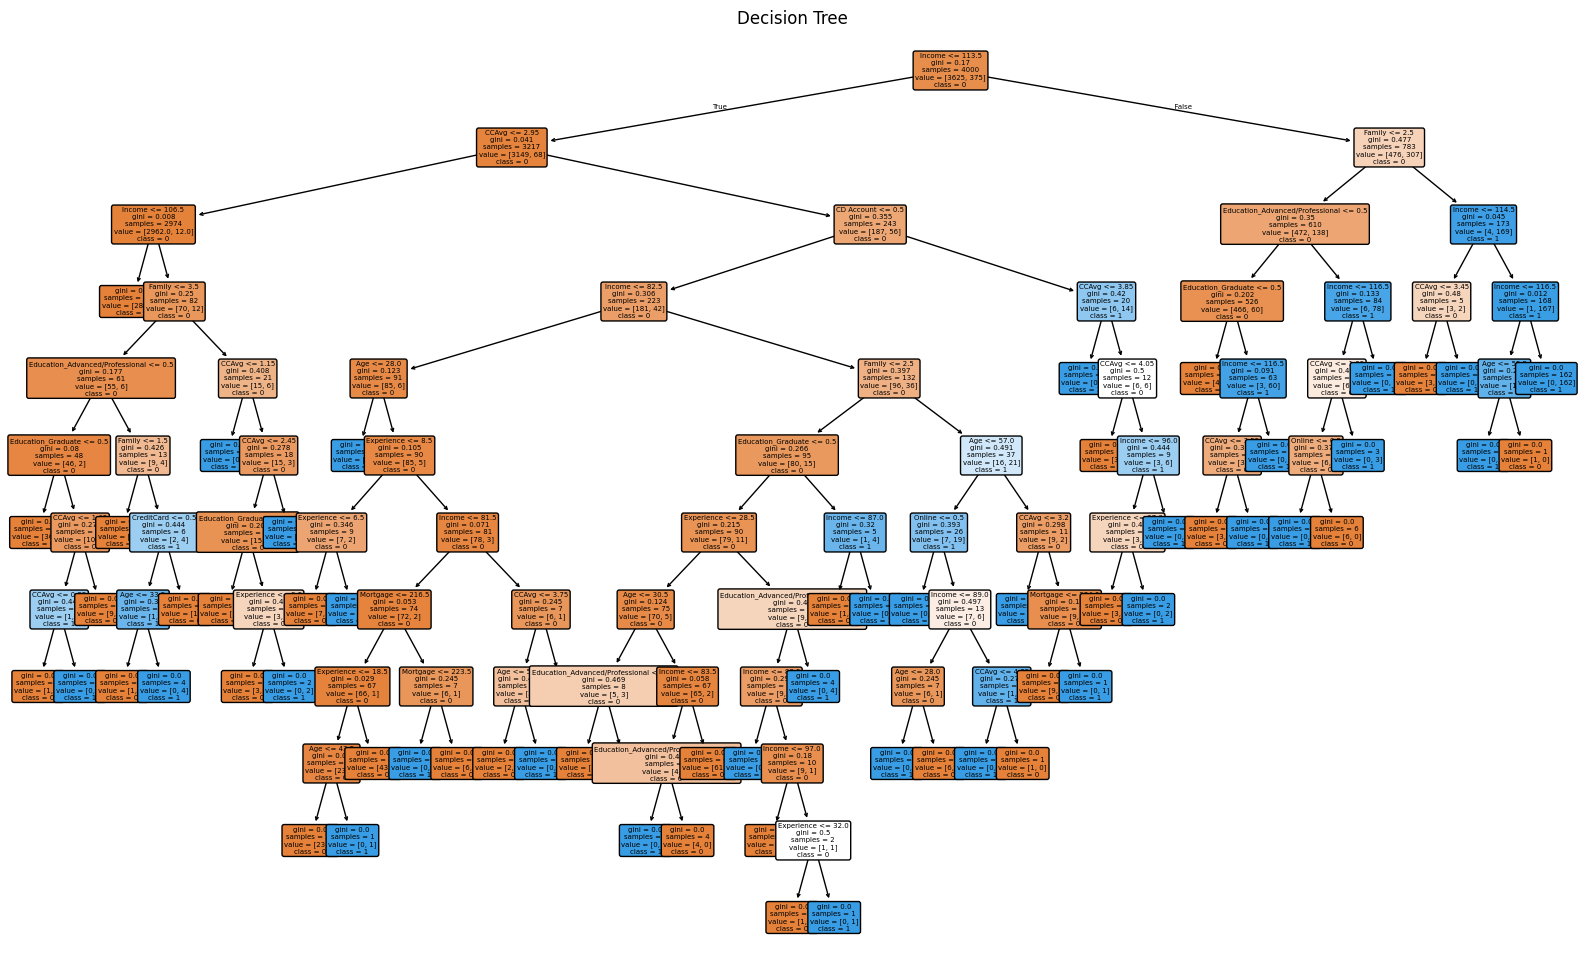

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

# Create a figure and axes
fig, ax = plt.subplots(figsize=(20, 12))

# Plot the decision tree with labels
tree.plot_tree(clf, ax=ax, feature_names=X.columns, class_names=['0', '1'], filled=True, rounded=True, fontsize=5)

# Set plot title and axis labels
ax.set_title("Decision Tree")
ax.set_xlabel("Features")
ax.set_ylabel("Target")

# Show the plot
plt.show()
